In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath("../utils"))  # repo utils/ (vendored sweep + shared helpers)


# Imports

In [4]:
file_path = '../data/raw_sweeps' # add path to data 

In [5]:
from sweep import sweep_load as sl
from sweep import raster
import numpy as np
import numpy.matlib
import matplotlib.pyplot as plt
from matplotlib import colors
from cycler import cycler
%matplotlib inline
from matplotlib.colors import Normalize
import matplotlib.image as mpimg
import h5py

from matplotlib import cm
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import LogLocator, SymmetricalLogLocator
import matplotlib.patches as mpatches

import sys
sys.path.append("../utils")
from utils import *
import cmcrameri.cm as cmc

# Physical constants
h = 6.626E-34  # Planck constant (J·s)
e = 1.6002E-19  # Elementary charge (C)
phi0 = h / e    # Flux quantum (Wb)
Rq = h/e**2
from matplotlib.gridspec import GridSpecFromSubplotSpec

In [6]:
scale = 0.56
plt.rcParams.update({
    # Font and font sizes
    'font.family': 'sans-serif',
    'axes.labelsize': 8, 
    'axes.titlesize': 8,
    'font.size': 9,
    'legend.title_fontsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,

    # Ticks
    'xtick.direction': 'in',
    'xtick.top': 'True',
    'ytick.direction': 'in',
    'ytick.right': 'True',

    'xtick.major.size': 5*scale,
    'xtick.major.width': 1.5*scale,
    'xtick.minor.size': 2.5*scale,
    'xtick.minor.width': 1.5*scale,

    'ytick.major.size': 5*scale,
    'ytick.major.width': 1.5*scale,
    'ytick.minor.size': 2.5*scale,
    'ytick.minor.width': 1.5*scale,


    # Linewidths
    'axes.linewidth': 1.5*scale,
    'lines.linewidth': 2.5*scale,
})


## d - Linecuts in Annular and Simple QM

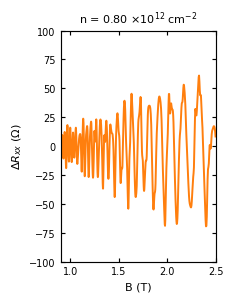

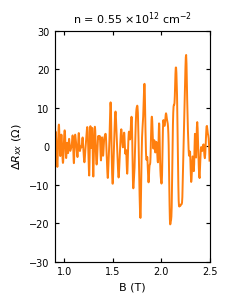

In [59]:
def plot_qo_linecuts(fig, ax, n, ylim):
    file = 1776
    contact = 1# choose which contact pair to plot = 1,2,3  
    data = sl.pload(file_path, file)
    ys = data['ys'][0]
    zs = data[f'sr830_{contact}_X']/data['sr830_4_X']
    zs = zs
    
    Vtgs = data['xs'][0]
    Vbgs = data['xs'][1]
    xs, _ = calculate_n_D(Vtgs, Vbgs, dtg=rmg19['default']['dtg'], dbg=rmg19['default']['dbg'])
    ny = 1000
    invBs = np.zeros((ny, zs.shape[1]))
    zs_detrended = np.zeros((ny, zs.shape[1]))
    for i, bcut in enumerate(zs.T):
        interp_invB, interp_Rxx = interp_rxx(ys, bcut, nx=ny) # invert B and interpolate for even spacing of points
        detrended, bg, _ = detrend_savgol(interp_invB, interp_Rxx, win=101, poly=3, max_win_frac=1)
        zs_detrended[:, i] = detrended
        invBs[:, i] = interp_invB

    linecut_ind = np.argmin(np.abs(n - xs))
    plot = ax.plot(1/invBs[:, linecut_ind], zs_detrended[:, linecut_ind], color="tab:orange")
    ax.set_ylabel(r'$\Delta R_{xx}$ ($\Omega$)')
    ax.set_xlabel(r'B (T)')
    ax.set_title("n = {:.2f}".format(xs[linecut_ind]) + r" $\times 10^{12}$ cm$^{-2}$")
    ax.set_xlim(0.9,2.5)
    ax.set_ylim(-ylim,ylim)
    return plot

fig = plt.figure(figsize=(2,3))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=1, vmin=-1e3, vmax=1E3)
plot = plot_qo_linecuts(fig, ax, 0.8, ylim=100)

fig = plt.figure(figsize=(2,3))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=1, vmin=-1e3, vmax=1E3)
plot = plot_qo_linecuts(fig, ax, 0.55, ylim=30)

### with inverse FFT

[-7.2271995 -0.j          7.21335325-0.25927802j -7.17075928+0.50234935j
 ...  7.09636052+0.71411796j -7.17075928-0.50234935j
  7.21335325+0.25927802j]
[-6.43771069-0.j          6.42692726+0.36952198j -6.39416426-0.71724298j
 ...  6.33821694-1.02274456j -6.39416426+0.71724298j
  6.42692726-0.36952198j]
[-6.43771069-0.j          6.42692726+0.36952198j -6.39416426-0.71724298j
 ...  6.33821694-1.02274456j -6.39416426+0.71724298j
  6.42692726-0.36952198j]
[-6.43771069-0.j          6.42692726+0.36952198j -6.39416426-0.71724298j
 ...  6.33821694-1.02274456j -6.39416426+0.71724298j
  6.42692726-0.36952198j]


/var/folders/q5/6h4h5k9n2t3g39wnfndbzhjr0000gn/T/ipykernel_32894/3962112869.py:42: RuntimeWarning: divide by zero encountered in divide
  recovered = recovered_windowed / hanning_window
/Users/sandeshkalantre/venvs/rhombo/lib/python3.9/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/sandeshkalantre/venvs/rhombo/lib/python3.9/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.5, 1.0, 'higher tone only')

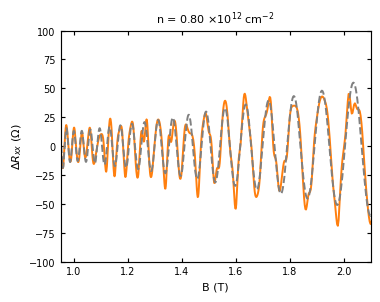

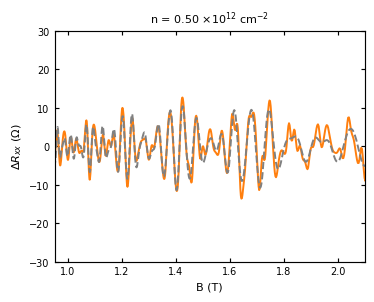

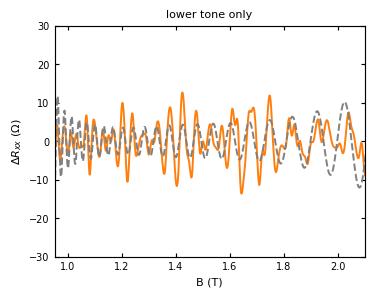

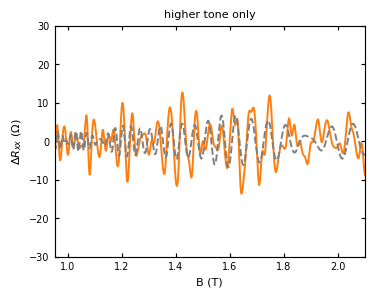

In [60]:
def plot_qo_linecuts_with_invFFT(fig, ax, n, ylim, fft_freq_window = [0.9,1.1]):
    file = 1776
    contact = 1# choose which contact pair to plot = 1,2,3  
    data = sl.pload(file_path, file)
    ys = data['ys'][0]
    zs = data[f'sr830_{contact}_X']/data['sr830_4_X']
    zs = zs
    
    Vtgs = data['xs'][0]
    Vbgs = data['xs'][1]
    xs, _ = calculate_n_D(Vtgs, Vbgs, dtg=rmg19['default']['dtg'], dbg=rmg19['default']['dbg'])
    ny = 1000
    invBs = np.zeros((ny, zs.shape[1]))
    zs_detrended = np.zeros((ny, zs.shape[1]))
    linecut_ind = np.argmin(np.abs(n - xs))
    
    interp_invB, interp_Rxx = interp_rxx(ys, zs[:,linecut_ind], nx=ny) # invert B and interpolate for even spacing of points
    detrended, bg, _ = detrend_savgol(interp_invB, interp_Rxx, win=101, poly=3, max_win_frac=1)

    plot = ax.plot(1/interp_invB, detrended, color="tab:orange")

    ne = xs[linecut_ind]
    padding = 5
    psd_vec, fft_freq_vec, fft_vec = make_vec_fft(interp_invB, detrended, ne, padding=padding, normalize=False, return_fft=True)
    print(fft_vec)
    
    
    #fft_vec = scipy.fft.fft(detrended)
    f1_ind = np.argmin(np.abs(fft_freq_vec - fft_freq_window[0]))
    f2_ind = np.argmin(np.abs(fft_freq_vec - fft_freq_window[1]))

    selective_fft_vec = np.zeros(len(fft_vec), dtype=np.complex128)
    N = len(fft_vec)
    selective_fft_vec[f1_ind:f2_ind] = fft_vec[f1_ind:f2_ind]
    selective_fft_vec[(N-f2_ind):(N-f1_ind)] = fft_vec[(N-f2_ind):(N-f1_ind)]
    #inv_fft_vec = scipy.fft.ifft(selective_fft_vec)

    sy = detrended.shape[0]
    hanning_window = scipy.signal.windows.hann(sy)
    recovered_padded = scipy.fft.ifft(selective_fft_vec)
    recovered_windowed = recovered_padded[sy*padding : sy*padding + sy]  # strip padding
    recovered = recovered_windowed / hanning_window
    
    ax.set_ylabel(r'$\Delta R_{xx}$ ($\Omega$)')
    ax.set_xlabel(r'B (T)')
    ax.set_title("n = {:.2f}".format(xs[linecut_ind]) + r" $\times 10^{12}$ cm$^{-2}$")
    ax.set_xlim(0.95,2.1)
    ax.set_ylim(-ylim,ylim)
    return plot, interp_invB, recovered

fig = plt.figure(figsize=(4,3))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=1, vmin=-1e3, vmax=1E3)
plot, interp_invB, inv_fft_vec = plot_qo_linecuts_with_invFFT(fig, ax, 0.8, ylim=100)

plt.plot(1/interp_invB, inv_fft_vec, ls="--", color="gray")

fig = plt.figure(figsize=(4,3))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=1, vmin=-1e3, vmax=1E3)
plot,  interp_invB, inv_fft_vec = plot_qo_linecuts_with_invFFT(fig, ax, 0.5, ylim=30, fft_freq_window = [1.5,3.5])
plt.plot(1/interp_invB, inv_fft_vec, ls="--", color="gray")

fig = plt.figure(figsize=(4,3))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=1, vmin=-1e3, vmax=1E3)
plot,  interp_invB, inv_fft_vec = plot_qo_linecuts_with_invFFT(fig, ax, 0.5, ylim=30, fft_freq_window = [1.8,2.1])
plt.plot(1/interp_invB, inv_fft_vec, ls="--", color="gray")
ax.set_title("lower tone only")

fig = plt.figure(figsize=(4,3))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=1, vmin=-1e3, vmax=1E3)
plot,  interp_invB, inv_fft_vec = plot_qo_linecuts_with_invFFT(fig, ax, 0.5, ylim=30, fft_freq_window = [2.1,3.0])
plt.plot(1/interp_invB, inv_fft_vec, ls="--", color="gray")
ax.set_title("higher tone only")